In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

sampler_instance = None  # injected before run_sampling

anneal_state = {
    'S': 1.0,
    'phase': 'normal',           # 'normal' | 'waiting' | 'annealing'
    'phase_start_iter': None,    # iter when current phase began
    'ref_unscaled_max_ld': None, # unscaled max_ld at start of current interval
    'ref_iter': None,            # iter when ref_unscaled_max_ld was recorded
}


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])) * anneal_state['S']
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_anneal5/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.537553  , 0.642705  , 0.549253  , 0.373063  , 0.397031  ],
        [0.53756087, 0.64271595, 0.54924315, 0.37305137, 0.39704231],
        [0.53754599, 0.64269731, 0.54925608, 0.37305516, 0.39702619],
        ...,
        [0.40182304, 0.33647013, 0.31897176, 0.6699286 , 0.76076807],
        [0.38275892, 0.34337164, 0.25155851, 0.73680829, 0.75172923],
        [0.39786643, 0.30952089, 0.32598766, 0.66448033, 0.78688875]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 2.02502927,  2.02448539,  2.01759835, ..., 51.65101256,
        50.49413478, 27.43438566], shape=(100000,))]

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1


array([[5.93187149, 0.97094686, 0.54681828, 9.84425398, 0.42417843]])

In [7]:
log_density(maxld_pt1)

array([5.6533477])

In [8]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [9]:
gwf.rhostat(h_pt1)

array(5.64387335)

In [10]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.77195879), array(0.14687301))

In [11]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

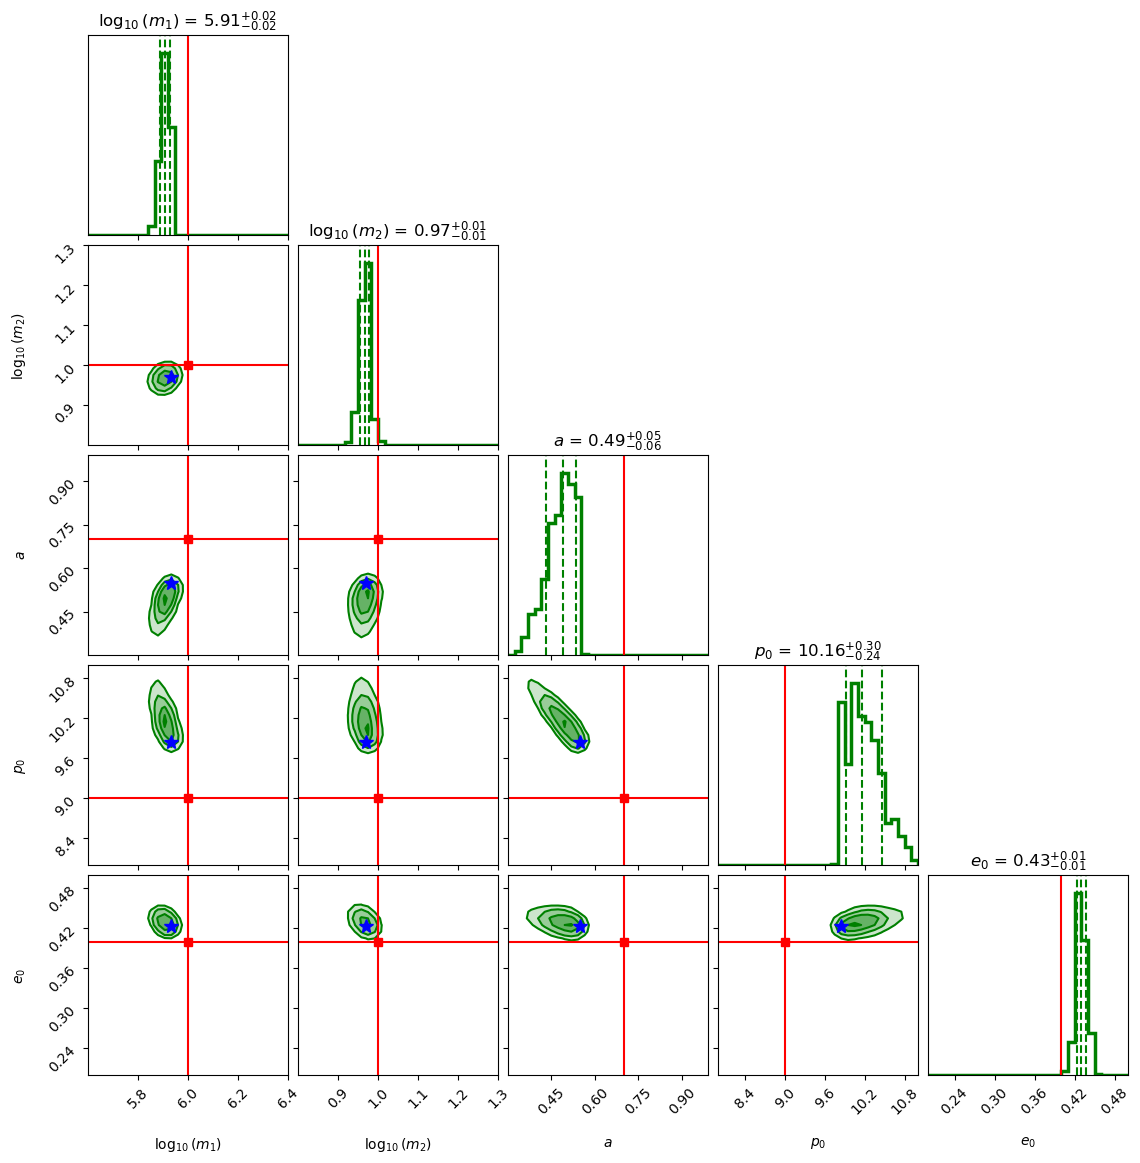

In [12]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


